
# Geolife dataset analysis
## Part 1: Analysis of small dataset
This notebook performs an analysis of the Geolife dataset, specifically:
- Number of trajectories for each means of transport
- Typical velocities for each means of transport
- Typical interval (time and space) between each point (based on the means of transport)
- Typical hours of the day when each means of transport is used
## Part 2: Analysis of whole dataset
This section also performs an analysis on the Geolife dataset as a whole. The analysis includes the following tasks:

1. Counting the number of users with and without means of transport.
2. Determining the number of locations associated with means of transport.
3. Analyzing the distribution of records per means of transport, including visualizing this information through plotting.
4. Computing and summarizing the statistics from the above tasks for the entire dataset.

The goal is to provide insights into the dataset's structure and the distribution of transportation-related data.


In [1]:
# contains multiple constant variables that result in a less verbose coding
import privkit as pk
import pandas as pd
import numpy as np
from datetime import datetime
from geopy.distance import geodesic
from privkit.utils import constants
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2025-06-23 20:55:00.217003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750704900.279603   28608 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750704900.299921   28608 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750704900.426187   28608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750704900.426210   28608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750704900.426211   28608 computation_placer.cc:177] computation placer alr

In [ ]:
# loading geolife dataset
dataset = pk.datasets.GeolifeDataset()
# Loading the dataset 
dataset.load_dataset()
# Extracting the location with the label not null
location_data = dataset.data
# Counting the number of users with and without means of transport
users_with_transport = location_data.data['uid'].nunique()
all_users = dataset.data.data['uid'].nunique()
users_without_transport = all_users - users_with_transport
print(f"Users with means of transport: {users_with_transport}")
print(f"Users without means of transport: {users_without_transport}")


Loading the geolife dataset
Dataset loaded from ./input/data/geolife.pkl
Users with means of transport: 182
Users without means of transport: 0


In [ ]:
# Counting the number of users with and without means of transport
users_with_transport = location_data.data['uid'].nunique()
all_users = dataset.data.data['uid'].nunique()
users_without_transport = all_users - users_with_transport
print(f"Users with means of transport: {users_with_transport}")
print(f"Users without means of transport: {users_without_transport}")

In [3]:
# Sorting the user having means of transport (labels)
location_data.data = location_data.data[location_data.data['label'].notnull()]
# location_data.data = location_data.data[location_data.data['uid'] == 163]
# location_data.data = location_data.data[location_data.data['label'].notnull()]
# location_data.data = location_data.data[:5]  # To limit the number of records

# Limiting the number of records for each user for testing purposes
location_data.data = location_data.data.groupby('uid').head(10)
# Printing the first few rows of the dataset
print("Location data sample:")
# prints a sample of the location data
print(location_data.data);

Location data sample:
              datetime        lat         lon         alt  tid  uid label  \
0  2007-05-13 08:35:06  40.073750  116.318133  150.918635    2  115   car   
1  2007-05-13 08:35:15  40.074167  116.317950  150.918635    2  115   car   
2  2007-05-13 08:35:22  40.074433  116.317817  150.918635    2  115   car   
3  2007-05-13 08:36:07  40.074617  116.317733  150.918635    2  115   car   
4  2007-05-13 08:36:19  40.074967  116.317583  203.412073    2  115   car   
..                 ...        ...         ...         ...  ...  ...   ...   
5  2007-10-08 23:18:16  40.003767  116.461700  111.548556    1  106   car   
6  2007-10-08 23:18:42  40.005900  116.461583  104.986877    1  106   car   
7  2007-10-08 23:19:02  40.006233  116.461650  108.267717    1  106   car   
8  2007-10-08 23:19:18  40.007017  116.461617  101.706037    1  106   car   
9  2007-10-08 23:19:38  40.007333  116.463983  141.076115    1  106   car   

    original_lat  original_lon  
0      40.073750    

In [16]:
# Sorting the data by user ID and datetime
location_data.data = location_data.data.sort_values(by=['uid', 'datetime'])

# Calculate previous coordinates and timestamps
location_data.data['prev_lat'] = location_data.data.groupby('uid')['lat'].shift(1)
location_data.data['prev_lon'] = location_data.data.groupby('uid')['lon'].shift(1)
location_data.data['prev_time'] = location_data.data.groupby('uid')['datetime'].shift(1)

# Compute distance in meters between consecutive points
location_data.data['distance'] = location_data.data.apply(
    lambda row: geodesic((row['lat'], row['lon']), (row['prev_lat'], row['prev_lon'])).meters
    if pd.notnull(row['prev_lat']) else 0, axis=1)

# Compute duration in seconds between timestamps
location_data.data['duration'] = (
    location_data.data['datetime'] - location_data.data['prev_time']
).dt.total_seconds().fillna(0)

# Compute velocity in m/s, avoiding division by zero
location_data.data['velocity'] = location_data.data['distance'] / \
    location_data.data['duration'].replace(0, np.nan)
location_data.data['velocity'] = location_data.data['velocity'].fillna(0)

# Drop rows without transport mode labels
location_data.data = location_data.data.dropna(subset=['label'])


In [17]:
# Count number of trajectory points per transport mode
print("Number of trajectory points for each means of transport:")
means_of_transport = location_data.data['label'].value_counts()
for transport, count in means_of_transport.items():
    print(f"{transport}: {count}")

# Compute average velocity per transport mode
print("\nTypical velocities for each means of transport:")
typical_velocities = location_data.data.groupby('label')['velocity'].mean().to_dict()
for transport, velocity in typical_velocities.items():
    print(f"{transport}: {velocity:.2f} m/s")

# Compute average distance per segment per transport mode
print("\nTypical distances for each means of transport:")
typical_distances = location_data.data.groupby('label')['distance'].mean().to_dict()
for transport, distance in typical_distances.items():
    print(f"{transport}: {distance:.2f} m")

# Compute average duration per segment per transport mode
print("\nTypical durations for each means of transport:")
typical_durations = location_data.data.groupby('label')['duration'].mean().to_dict()
for transport, duration in typical_durations.items():
    print(f"{transport}: {duration:.2f} seconds")

# Compute most typical hours of usage per transport mode
location_data.data['hour'] = location_data.data['datetime'].dt.hour
typical_hours = location_data.data.groupby('label')['hour'].apply(lambda x: x.mode().tolist()).to_dict()

print("\nTypical hours of the day when each means of transport is used:")
for transport, hours in typical_hours.items():
    print(f"{transport}: {hours}")


Number of trajectory points for each means of transport:
walk: 279
bike: 108
bus: 99
car: 90
taxi: 40
train: 10
subway: 10

Typical velocities for each means of transport:
bike: 3.19 m/s
bus: 5.72 m/s
car: 7.52 m/s
subway: 7.04 m/s
taxi: 5.94 m/s
train: 20.21 m/s
walk: 2.37 m/s

Typical distances for each means of transport:
bike: 79.17 m
bus: 103.82 m
car: 190.89 m
subway: 38.49 m
taxi: 548.50 m
train: 299.07 m
walk: 54.60 m

Typical durations for each means of transport:
bike: 5686.87 seconds
bus: 34.70 seconds
car: 18.28 seconds
subway: 5.30 seconds
taxi: 62.33 seconds
train: 13.30 seconds
walk: 12007.90 seconds

Typical hours of the day when each means of transport is used:
bike: [5]
bus: [6, 9]
car: [23]
subway: [14]
taxi: [0, 5, 15, 17]
train: [16]
walk: [14]


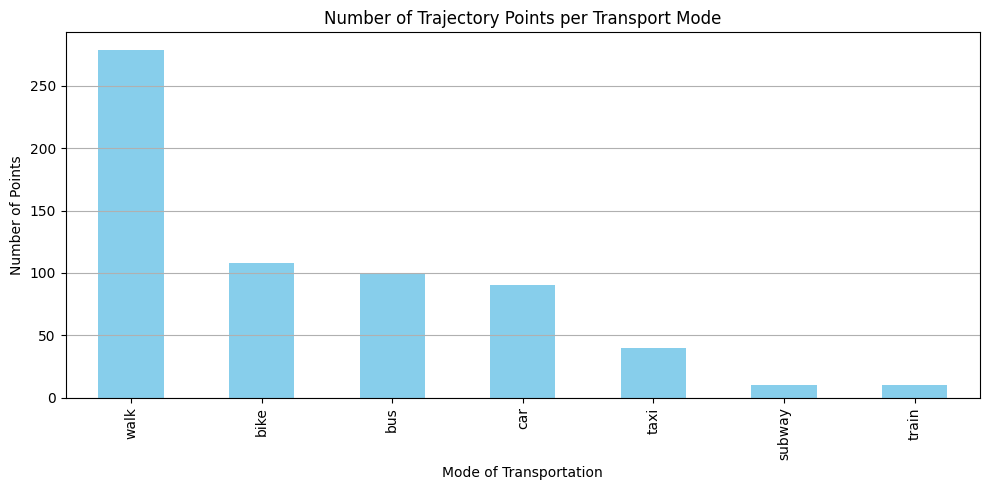

In [6]:
# Analyzing the distribution of records per means of transport
means_of_transport.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title("Number of Trajectory Points per Transport Mode")
plt.xlabel("Mode of Transportation")
plt.ylabel("Number of Points")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


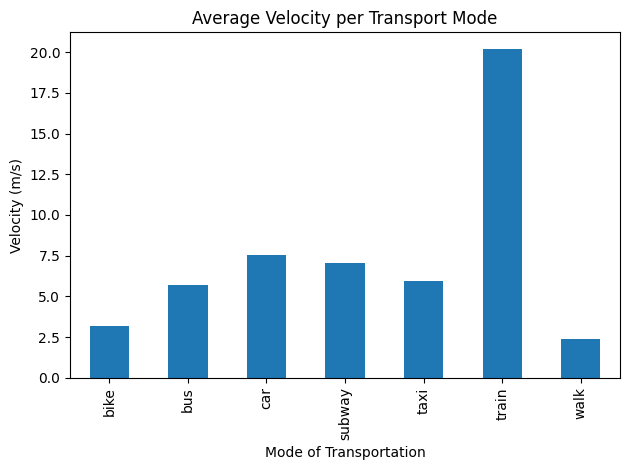

In [7]:
# Analyzing the average velocity per means of transport
plt.figure()
pd.Series(typical_velocities).plot(kind='bar')
plt.title("Average Velocity per Transport Mode")
plt.xlabel("Mode of Transportation")
plt.ylabel("Velocity (m/s)")
plt.tight_layout()
plt.show()

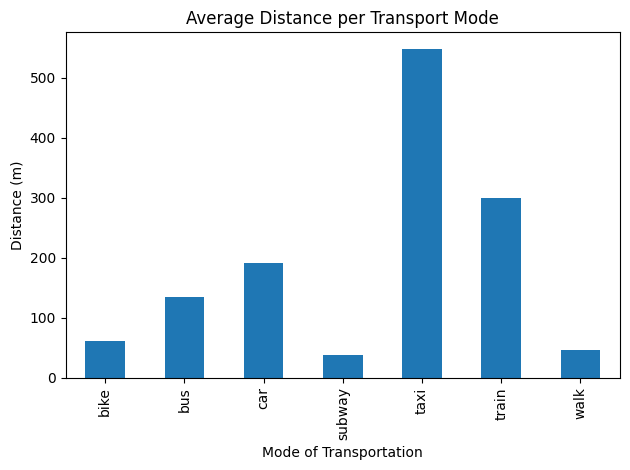

In [ ]:
# Analyzing the average disance per means of transport
plt.figure()
pd.Series(typical_distances).plot(kind='bar')
plt.title("Average Distance per Transport Mode")
plt.xlabel("Mode of Transportation")
plt.ylabel("Distance (m)")
plt.tight_layout()
plt.show()

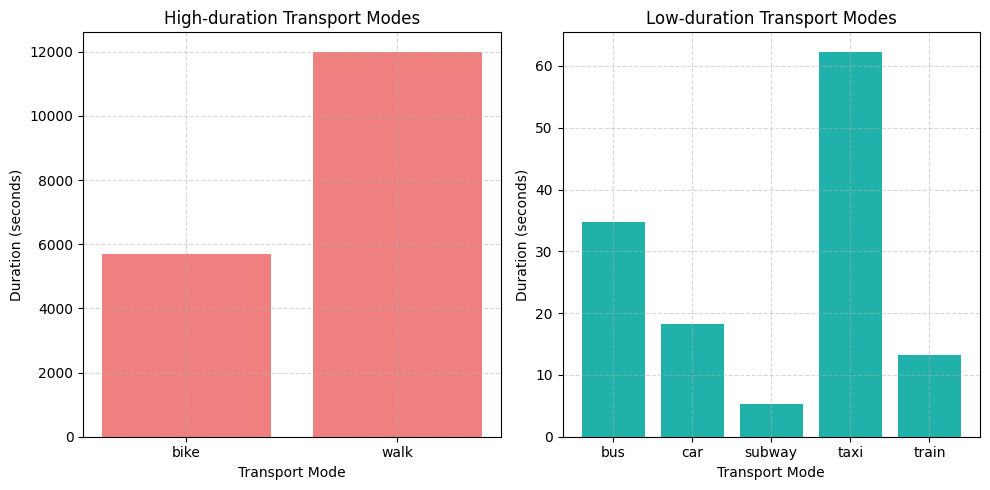

In [33]:
# Analyzing the average duration per means of transport
duration_series = pd.Series(typical_durations)

# Grouping transport modes by duration scale
high_duration = {k: v for k, v in typical_durations.items() if v > 1000}
low_duration = {k: v for k, v in typical_durations.items() if v <= 1000}

# Define a constant for the label "Transport Mode"
TRANSPORT_MODE_LABEL = "Transport Mode"

# Create two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot high-duration transport modes (e.g., walk, bike)
axs[0].bar(high_duration.keys(), high_duration.values(), color='lightcoral')
axs[0].set_title("High-duration Transport Modes")
axs[0].set_xlabel(TRANSPORT_MODE_LABEL)
axs[0].set_ylabel("Duration (seconds)")
axs[0].grid(True, linestyle='--', alpha=0.5)

# Plot low-duration transport modes (e.g., subway, taxi)
axs[1].bar(low_duration.keys(), low_duration.values(), color='lightseagreen')
axs[1].set_title("Low-duration Transport Modes")
axs[1].set_xlabel(TRANSPORT_MODE_LABEL)
axs[1].set_ylabel("Duration (seconds)")
axs[1].grid(True, linestyle='--', alpha=0.5)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

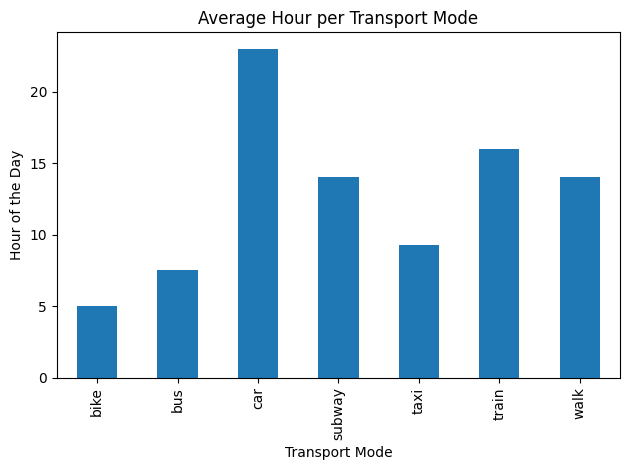

In [12]:
# Analyzing the average hour per means of transport
average_hours = {k: np.mean(v) for k, v in typical_hours.items()}

plt.figure()
pd.Series(average_hours).plot(kind='bar')
plt.title("Average Hour per Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Hour of the Day")
plt.tight_layout()
plt.show()